# Two-State Two-Action Mean-Field Control
## Simplex- versus logit-perturbed MF-REINFORCE

---

### 1. Benchmark

The state and action spaces are $$\mathcal X=\{0, 1\}, \qquad \mathcal A=\{\mathrm{ST},\mathrm{MV}\}.$$ Choosing $\mathrm{ST}$ leaves the state unchanged, whereas choosing $\mathrm{MV}$ switches from $x$ to $1-x$ with probability $\lambda_x$: $$P(1-x\mid x, a)=\lambda_x\mathbf 1_{\{a=\mathrm{MV}\}}, \qquad P(x\mid x,a)=1-\lambda_x\mathbf 1_{\{a=\mathrm{MV}\}}.$$

The running and terminal rewards are $$r(x,a,\mu)=\mathbf 1_{\{x=1\}}-\mu(1)^2-\kappa W_1(\mu,\bar\mu),\qquad g(x,\mu)=r(x,\mu),$$ with $$\lambda_0=0.5,\qquad\lambda_1=0.8,\qquad\kappa=10,\qquad\bar\mu=(0.6,0.4),\qquad T=2.$$ On $\{0,1\}$, $W_1(\mu,\bar\mu)=|\mu(1)-0.4|$.

The optimal stationary policy is known explicitly: $$\pi^\star(\mathrm{ST}\mid 0)=0.2,\qquad\pi^\star(\mathrm{ST}\mid 1)=0.25.$$ It sends every initial population law to $\bar\mu$ after one step. For the validation law $\mu_0^{\mathrm{val}}=(0.2,0.8)$, the exact optimal value is $J^\star=-3.36$.

---

### 2. Perturbation mechanisms

| Method | Perturbed population argument | Auxiliary sensitivity |
|---|---|---|
| **Logit perturbation** | $\displaystyle M_t^{\varepsilon,\theta}=\operatorname{softmax}\!\left(\log\mu_t^\theta+\varepsilon\Lambda_t\right),\quad \Lambda_t\sim\mathcal N(0,I_2)$ | $\nabla_\theta\operatorname{logit}(\mu_t^\theta)$ |
| **Simplex perturbation** | $\displaystyle M_t^{\lambda,\theta}=(1-\lambda)\mu_t^\theta+\lambda q_t,\quad q_t\in\Delta_2^\circ$ | $\displaystyle D_t^\theta=\nabla_\theta\mu_t^\theta$ |

For the simplex estimator, the explicit density of $M_t^{\lambda,\theta}$ yields the correction $$-\frac{1-\lambda}{\lambda}\sum_{t=0}^{T}\sum_{k=1}^{N-1} H_k(q_t)\,D_t^\theta(k),$$ where $H_k$ is the score of the reference density on the simplex. The implementable algorithm replaces $D_t^\theta$ by an auxiliary estimate $\widehat D_t^{\eta,n,\theta}$; in this notebook, $\eta=\lambda$.

The raw parameters $\lambda$ and $\varepsilon$ are not geometrically comparable. We therefore calibrate them through the effective perturbation radius $$\delta(\alpha)= \mathbb E\!\left[d_{\mathrm{TV}}\!\left(M_t^{\alpha,\theta},\mu_t^\theta\right)\right]$$ over a common reference distribution of population laws, and compare the two methods over the overlap of their calibrated radii.

The reference populations are $100{,}000$ samples from $\mathrm{Dirichlet}(1,1)$.

---

### 4. Theoretical guarantees and expected trade-off

Under the regularity assumptions developed in the discrete-state analysis:

- **Simplex perturbation size**
  $$
  d_{\mathrm{TV}}\!\left(M_t^{\lambda,\theta},\mu_t^\theta\right)\leq \lambda
  \quad\text{pathwise}.
  $$

- **Logit perturbation size**
  $$
  \mathbb E\!\left[
  d_{\mathrm{TV}}\!\left(M_t^{\varepsilon,\theta},\mu_t^\theta\right)
  \right]\leq \frac{\varepsilon}{2}.
  $$

- **Objective and gradient consistency**
  $$
  \sup_{\theta}|J^\lambda(\theta)-J(\theta)|=O(\lambda),
  \qquad
  \|\nabla_\theta J^\lambda(\theta)-\nabla_\theta J(\theta)\|=O(\lambda),
  $$
  while the logit-perturbed gradient converges to the true gradient as
  $\varepsilon\downarrow0$, with first-order perturbation bias under the corresponding smoothness assumptions.

Suppressing problem-dependent constants, the simplex MSE decomposition has the form
$$
\operatorname{MSE}_{\mathrm{simp}}
\lesssim
\frac{\sigma_{\lambda,\eta,n}^2}{B}
+\lambda^2
+\left(\frac{1-\lambda}{\lambda}\right)^2
\left(A_\eta^2+\frac{V_\eta}{n}\right),
$$
whereas the logit analysis gives the schematic dependence
$$
\operatorname{MSE}_{\mathrm{logit}}
\lesssim
\varepsilon^2
+\frac{1}{B\varepsilon^2}
+\frac{1}{nB\varepsilon^4}
\sum_{t=0}^{T}C_t\varepsilon^{-2t}.
$$

The central phenomenon is therefore a **bias--variance trade-off**:

- a smaller perturbation better approximates the true gradient;
- but the perturbation score becomes larger and amplifies sensitivity-estimation noise;
- a larger perturbation stabilizes the estimator but optimizes a more distorted objective.

---

### 5. Simulator and arithmetic complexity

Let $B$ be the number of main trajectories, $n$ the auxiliary batch size, $T$ the horizon, and $\widetilde N$ the number of particles used to estimate the unperturbed population flow.

With exact population propagation, the transition counts per policy update are
$$
C_{\mathrm{sim}}^{\mathrm{simp}}=T(B+n),
$$
and, for the original logit MF-REINFORCE construction with an independent truncated sensitivity estimate for each main trajectory,
$$
C_{\mathrm{sim}}^{\mathrm{logit}}
=
BT+Bn\frac{T(T+1)}{2}.
$$
A particle approximation of the unperturbed flow adds $\widetilde N T$ transitions to both methods. The dominant computational cost is the number of simulated state transitions required to produce one policy-gradient update.

For $T=2$:

| Protocol | Simplex $(B,n)$ | Logits $(B,n)$ | Transitions per update |
|---|---:|---:|---:|
| Equal parameters, exact flow | $(200,10)$ | $(200,10)$ | $420$ vs. $6400$ |
| Equal simulator budget, exact flow | $(2800,400)$ | $(200,10)$ | $6400$ each |
| Equal simulator budget, particle flow | $(2800,400)$ | $(200,10)$ | $6800$ each with $\widetilde N=200$ |

The equal-parameter comparison measures behavior per optimizer step. The equal-budget comparisons measure statistical efficiency per simulator call.

---

### 6. Experimental protocols

1. **Exact flow, equal parameters.**  
   Both estimators use $(B,n)=(200,10)$. This reproduces the nominal reference setting but exposes the large difference in simulator cost.

2. **Exact flow, equal simulator budget.**  
   Logits uses $(B,n)=(200,10)$; simplex uses $(B,n)=(2800,400)$. Both spend $6400 transitions per update.

3. **Particle flow, equal simulator budget.**  
   Both methods condition on the same one-per-update empirical approximation of the unperturbed population flow using $200$ particles. Both spend $6800$ transitions per update.

All comparisons use paired initializations, paired training-law sequences, identical optimization settings, and the same evaluation schedule.

---

### 7. Reported diagnostics

The notebook reports:

- exact validation value and optimality gap;
- absolute errors in
  $\pi_\theta(\mathrm{ST}\mid0)$ and
  $\pi_\theta(\mathrm{ST}\mid1)$;
- the corrected population-tracking error
  $$
  \mathcal E_{\mathrm{flow}}(\theta)
  =
  \frac1T\sum_{t=1}^{T}
  \left|\mu_t^\theta(1)-0.4\right|;
  $$
- empirical gradient bias, covariance trace, cosine alignment, and MSE relative to the exact-gradient oracle;
- simulated-transition counts and wall-clock time.

The three protocols answer progressively stronger questions:

- Does either perturbation train more effectively at the same nominal $(B,n)$?
- Which estimator is more accurate at a fixed simulator budget?
- How much performance is lost when the population flow itself must be learned from particles?

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional, Tuple
import copy
import random
import sys
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm import tqdm

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = (ROOT / "..").resolve()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from mfc.algorithms import SimplexPerturbedMFREINFORCE, LogitsPerturbedMFREINFORCE
from mfc.environments import TwoStateMFC, TwoStateConfig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)


def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)


set_seed(0)
print(device)

cuda


In [2]:
# Two-state helpers: training, calibration, metrics, diagnostics, and plotting.
def format_runtime(seconds: Optional[float]) -> str:
    if seconds is None:
        return "not set"
    seconds = float(seconds)
    hours, remainder = divmod(int(seconds), 3600)
    minutes, secs = divmod(remainder, 60)
    if hours:
        return f"{hours:d}h {minutes:02d}m {secs:02d}s"
    if minutes:
        return f"{minutes:d}m {secs:02d}s"
    return f"{seconds:.1f}s"


def std_ddof(n: int) -> int:
    return 1 if n > 1 else 0


def safe_name(name: str) -> str:
    return "".join(ch.lower() if ch.isalnum() else "_" for ch in name).strip("_") or "twostate"


def aligned_validation_history(runs):
    min_len = min(len(run["history"]["validation_value"]) for run in runs)
    episodes = np.asarray(runs[0]["history"]["episode"][:min_len], dtype=float)
    values = np.asarray([run["history"]["validation_value"][:min_len] for run in runs], dtype=float)
    return episodes, values


def aligned_history_metric(runs, key: str):
    min_len = min(len(run["history"].get(key, [])) for run in runs)
    if min_len == 0:
        return np.asarray([]), np.asarray([])
    episodes = np.asarray(runs[0]["history"]["episode"][:min_len], dtype=float)
    values = np.asarray([run["history"][key][:min_len] for run in runs], dtype=float)
    return episodes, values


def simulator_transitions_per_update(
    algorithm_name: str,
    horizon: int,
    B: int,
    n_aux_or_inner: int,
    flow_mode: str = "exact",
    flow_particles: int = 0,
) -> int:
    if algorithm_name == "Simplex":
        core = (B + n_aux_or_inner) * horizon
    elif algorithm_name == "Logits":
        core = B * horizon + B * n_aux_or_inner * horizon * (horizon + 1) // 2
    else:
        raise ValueError(f"Unknown algorithm_name={algorithm_name!r}.")

    flow_cost = 0 if flow_mode == "exact" else flow_particles * horizon
    return int(core + flow_cost)


def simulator_cost_table(
    horizon: int,
    flow_mode: str,
    budgets: Dict[str, Dict[str, int]],
    flow_particles: int = 0,
) -> pd.DataFrame:
    rows = []
    simplex_cost = simulator_transitions_per_update(
        "Simplex",
        horizon,
        budgets["Simplex"]["B"],
        budgets["Simplex"]["n"],
        flow_mode=flow_mode,
        flow_particles=flow_particles,
    )
    for algorithm_name in ["Simplex", "Logits"]:
        budget = budgets[algorithm_name]
        cost = simulator_transitions_per_update(
            algorithm_name,
            horizon,
            budget["B"],
            budget["n"],
            flow_mode=flow_mode,
            flow_particles=flow_particles,
        )
        rows.append(
            {
                "algorithm": algorithm_name,
                "B": budget["B"],
                "n": budget["n"],
                "horizon": horizon,
                "flow_mode": flow_mode,
                "flow_particles": flow_particles if flow_mode == "particle" else 0,
                "simulator_transitions_per_update": cost,
                "ratio_vs_simplex": cost / simplex_cost,
            }
        )
    return pd.DataFrame(rows).set_index("algorithm")


def fixed_validation_law(config: TwoStateConfig) -> torch.Tensor:
    return torch.tensor([0.2, 0.8], dtype=config.dtype, device=config.device)


def sample_twostate_initial_laws(config: TwoStateConfig, count: int) -> torch.Tensor:
    mu1 = config.low + (config.high - config.low) * torch.rand(
        count,
        dtype=config.dtype,
        device=config.device,
    )
    return torch.stack([1.0 - mu1, mu1], dim=-1).detach().cpu()


def prepare_paired_run_plans(config: TwoStateConfig, seed_base: int = 11_000, training_runs: Optional[int] = None):
    n_runs = config.training_runs if training_runs is None else training_runs
    plans = []
    for run_idx in range(n_runs):
        seed = seed_base + run_idx
        set_seed(seed)
        plans.append(
            {
                "run_idx": run_idx,
                "seed": seed,
                "initial_control": {"theta": torch.zeros(2, dtype=config.dtype, device=config.device).cpu()},
                "initial_laws": sample_twostate_initial_laws(config, config.n_train),
            }
        )
    return plans


def payload_from_record(record: Dict[str, object]) -> Dict[str, torch.Tensor]:
    return {"theta": record["theta"].detach().cpu().clone()}


def load_theta(config: TwoStateConfig, payload: Dict[str, torch.Tensor], trainable: bool = True):
    theta = payload["theta"].to(dtype=config.dtype, device=config.device).detach().clone()
    return torch.nn.Parameter(theta) if trainable else theta


def theta_for_estimator(theta):
    return theta.detach() if isinstance(theta, torch.nn.Parameter) else theta


def assign_ascent_gradient(theta: torch.nn.Parameter, grad_hat: torch.Tensor) -> None:
    theta.grad = -grad_hat.detach().clone().reshape_as(theta)


def training_population_flow(
    env: TwoStateMFC,
    algorithm,
    theta,
    mu0: torch.Tensor,
    horizon: int,
    flow_mode: str,
    flow_particles: int,
) -> torch.Tensor:
    ctrl = theta_for_estimator(theta)
    if flow_mode == "exact":
        with torch.no_grad():
            return env.exact_population_flow(ctrl, mu0, horizon).detach()
    if flow_mode == "particle":
        return algorithm.estimate_population_flow(ctrl, mu0, flow_particles, horizon=horizon).detach()
    raise ValueError(f"Unknown flow_mode={flow_mode!r}.")


def reference_metrics(env: TwoStateMFC, theta, mu0: torch.Tensor, horizon: int) -> Dict[str, object]:
    ctrl = theta_for_estimator(theta)
    with torch.no_grad():
        flow = env.exact_population_flow(ctrl, mu0, horizon).detach()
        value = env.exact_value(ctrl, mu0, horizon).detach()
        policy = env.policy_probs(ctrl).detach()
        optimal = env.optimal_policy().detach()
        st_errors = (policy[:, 0] - optimal[:, 0]).abs()
        flow_error = (flow[1:, 1] - env.target_B[1]).abs().mean()
    return {
        "value": float(value.item()),
        "policy": policy.cpu(),
        "optimal_policy": optimal.cpu(),
        "final_distribution": flow[-1].cpu(),
        "flow": flow.cpu(),
        "policy_error_st_0": float(st_errors[0].item()),
        "policy_error_st_1": float(st_errors[1].item()),
        "policy_error_mean": float(st_errors.mean().item()),
        "flow_error": float(flow_error.item()),
        "err_pi_st_0": float(st_errors[0].item()),
        "err_pi_st_1": float(st_errors[1].item()),
    }


def record_numeric_history(history: Dict[str, List[float]], metrics: Dict[str, object]) -> None:
    for key, value in metrics.items():
        if isinstance(value, (int, float, np.integer, np.floating)):
            history.setdefault(key, []).append(float(value))


def train_twostate_method(
    method: str,
    config: TwoStateConfig,
    perturbation_values,
    budget: Dict[str, int],
    run_plans,
    flow_mode: str,
    flow_particles: int,
    train_horizon: int,
    validation_horizon: int,
    label: str,
    early_stopping_patience: Optional[int] = None,
    early_stopping_min_delta: float = 0.0,
    max_runtime_seconds: Optional[float] = None,
    save_dir: Path = ROOT / "models" / "TwoStateExactParticle",
):
    algorithm_name = "Simplex" if method == "simplex" else "Logits"
    B = int(budget["B"])
    n_aux_or_inner = int(budget["n"])
    transitions_per_update = simulator_transitions_per_update(
        algorithm_name,
        train_horizon,
        B,
        n_aux_or_inner,
        flow_mode=flow_mode,
        flow_particles=flow_particles,
    )
    save_root = Path(save_dir) / safe_name(label) / safe_name(algorithm_name)
    save_root.mkdir(parents=True, exist_ok=True)
    fixed_mu0 = fixed_validation_law(config)
    results = {}

    for perturbation in perturbation_values:
        perturbation = float(perturbation)
        results[perturbation] = []
        eps_start = time.perf_counter()
        for run_idx, plan in enumerate(run_plans):
            set_seed(plan["seed"])
            env = TwoStateMFC(config)
            theta = load_theta(config, plan["initial_control"], trainable=True)
            optimizer = torch.optim.Adam([theta], lr=config.lr)
            algorithm = SimplexPerturbedMFREINFORCE(env) if method == "simplex" else LogitsPerturbedMFREINFORCE(env)
            history: Dict[str, List[float]] = {
                "episode": [],
                "validation_value": [],
                "train_return_mean": [],
                "grad_norm": [],
                "elapsed_seconds": [],
            }
            run_start = time.perf_counter()
            stop_reason = "completed"
            episodes_completed = 0
            best_validation = -float("inf")
            best_episode = None
            best_theta = None

            progress = tqdm(range(config.n_train), desc=f"{label} {algorithm_name} p={perturbation} run={run_idx}")
            for episode in progress:
                if max_runtime_seconds is not None and time.perf_counter() - run_start >= max_runtime_seconds:
                    stop_reason = f"max_runtime_{format_runtime(max_runtime_seconds)}"
                    break

                mu0 = plan["initial_laws"][episode].to(dtype=config.dtype, device=config.device)
                mu_flow = training_population_flow(env, algorithm, theta, mu0, train_horizon, flow_mode, flow_particles)
                ctrl = theta_for_estimator(theta)

                if method == "simplex":
                    D_hat = algorithm.estimate_sensitivity(ctrl, mu_flow, perturbation, n_aux_or_inner)
                    grad_hat, diag = algorithm.gradient_estimate(ctrl, mu_flow, D_hat, perturbation, B, baseline="batch_mean")
                else:
                    grad_hat, diag = algorithm.gradient_estimate(
                        ctrl,
                        mu0,
                        perturbation,
                        B,
                        n_aux_or_inner,
                        flow_particles=1,
                        horizon=train_horizon,
                        mu_flow=mu_flow,
                    )

                optimizer.zero_grad(set_to_none=True)
                assign_ascent_gradient(theta, grad_hat)
                optimizer.step()
                episodes_completed = episode + 1

                if episode % config.validate_every == 0 or episode == config.n_train - 1:
                    metrics = reference_metrics(env, theta, fixed_mu0, validation_horizon)
                    validation_value = metrics["value"]
                    history["episode"].append(episode)
                    history["validation_value"].append(validation_value)
                    history["train_return_mean"].append(float(diag["mean_return"].detach().item()))
                    history["grad_norm"].append(float(diag["grad_norm"].detach().item()))
                    history["elapsed_seconds"].append(time.perf_counter() - run_start)
                    record_numeric_history(history, metrics)
                    progress.set_postfix(value=f"{validation_value:.4g}", grad=f"{history['grad_norm'][-1]:.3g}")

                    if validation_value > best_validation + early_stopping_min_delta:
                        best_validation = validation_value
                        best_episode = episode
                        best_theta = theta.detach().cpu().clone()
                    else:
                        pass

                    if early_stopping_patience is not None:
                        checks_since_best = len(history["validation_value"]) - 1 - history["validation_value"].index(best_validation)
                        if checks_since_best >= early_stopping_patience:
                            stop_reason = "early_stopping"
                            break

            final_metrics = reference_metrics(env, theta, fixed_mu0, validation_horizon)
            theta_cpu = theta.detach().cpu().clone()
            record = {
                "algorithm": algorithm_name,
                "flow_mode": flow_mode,
                "flow_particles": flow_particles if flow_mode == "particle" else 0,
                "perturbation": perturbation,
                "epsilon": perturbation,
                "run_idx": run_idx,
                "seed": plan["seed"],
                "theta": theta_cpu,
                "final_policy": final_metrics["policy"],
                "optimal_policy": final_metrics["optimal_policy"],
                "final_distribution": final_metrics["final_distribution"],
                "history": history,
                "final_value": final_metrics["value"],
                "reference_metrics": final_metrics,
                "runtime_seconds": time.perf_counter() - run_start,
                "episodes_completed": episodes_completed,
                "main_trajectories": B,
                "auxiliary_trajectories": n_aux_or_inner,
                "simulator_transitions_per_update": transitions_per_update,
                "total_simulator_transitions": transitions_per_update * episodes_completed,
                "stop_reason": stop_reason,
                "best_validation_value": best_validation,
                "best_episode": best_episode,
                "best_theta": best_theta,
            }
            save_path = save_root / f"{flow_mode}_p_{str(perturbation).replace('.', 'p')}_run_{run_idx}.pt"
            record["save_path"] = str(save_path)
            torch.save({"config": config, "record": record}, save_path)
            results[perturbation].append(record)
            print(
                f"{label} {algorithm_name} p={perturbation} run={run_idx} "
                f"value={record['final_value']:.6g} cost/update={transitions_per_update} "
                f"runtime={format_runtime(record['runtime_seconds'])}"
            )
        print(f"{label} {algorithm_name} p={perturbation} completed in {format_runtime(time.perf_counter() - eps_start)}")
    return results


def run_twostate_scenario(
    name: str,
    config: TwoStateConfig,
    simplex_lambdas,
    logit_epsilons,
    budgets: Dict[str, Dict[str, int]],
    run_plans,
    flow_mode: str,
    flow_particles: int = 0,
    train_horizon: Optional[int] = None,
    validation_horizon: Optional[int] = None,
    early_stopping_patience: Optional[int] = None,
    max_runtime_seconds: Optional[float] = None,
):
    train_horizon = config.T if train_horizon is None else train_horizon
    validation_horizon = config.T if validation_horizon is None else validation_horizon
    costs = simulator_cost_table(train_horizon, flow_mode, budgets, flow_particles=flow_particles)
    display(costs.round(4))
    simplex_results = train_twostate_method(
        "simplex",
        config,
        simplex_lambdas,
        budgets["Simplex"],
        run_plans,
        flow_mode,
        flow_particles,
        train_horizon,
        validation_horizon,
        label=name,
        early_stopping_patience=early_stopping_patience,
        max_runtime_seconds=max_runtime_seconds,
    )
    logits_results = train_twostate_method(
        "logits",
        config,
        logit_epsilons,
        budgets["Logits"],
        run_plans,
        flow_mode,
        flow_particles,
        train_horizon,
        validation_horizon,
        label=name,
        early_stopping_patience=early_stopping_patience,
        max_runtime_seconds=max_runtime_seconds,
    )
    return {
        "name": name,
        "flow_mode": flow_mode,
        "flow_particles": flow_particles if flow_mode == "particle" else 0,
        "budgets": copy.deepcopy(budgets),
        "costs": costs,
        "train_horizon": train_horizon,
        "validation_horizon": validation_horizon,
        "results": {"Simplex": simplex_results, "Logits": logits_results},
    }


def sample_simplex_q(config: TwoStateConfig, n: int) -> torch.Tensor:
    u = config.q_sigma * torch.randn(n, 1, dtype=config.dtype, device=config.device)
    logits = torch.cat([u, torch.zeros(n, 1, dtype=config.dtype, device=config.device)], dim=-1)
    q = torch.softmax(logits, dim=-1).clamp_min(config.q_clip)
    return q / q.sum(dim=-1, keepdim=True)


def calibrate_perturbation_radii(
    config: TwoStateConfig,
    reference_laws: torch.Tensor,
    simplex_values,
    logit_values,
    num_samples: int = 20_000,
) -> pd.DataFrame:
    reference_laws = reference_laws.to(dtype=config.dtype, device=config.device)
    index = torch.randint(reference_laws.shape[0], (num_samples,), device=config.device)
    mu = reference_laws[index].clamp_min(config.q_clip)
    mu = mu / mu.sum(dim=-1, keepdim=True)
    q = sample_simplex_q(config, num_samples)
    lambdas = torch.randn(num_samples, 2, dtype=config.dtype, device=config.device)
    log_mu = torch.log(mu)
    rows = []

    for value in simplex_values:
        perturbed = (1.0 - float(value)) * mu + float(value) * q
        radii = 0.5 * (mu - perturbed).abs().sum(dim=-1).detach().cpu().numpy()
        rows.append(
            {
                "algorithm": "Simplex",
                "parameter": float(value),
                "tv_mean": radii.mean(),
                "tv_median": np.median(radii),
                "tv_std": radii.std(ddof=0),
                "tv_p10": np.quantile(radii, 0.10),
                "tv_p90": np.quantile(radii, 0.90),
            }
        )
    for value in logit_values:
        perturbed = torch.softmax(log_mu + float(value) * lambdas, dim=-1)
        radii = 0.5 * (mu - perturbed).abs().sum(dim=-1).detach().cpu().numpy()
        rows.append(
            {
                "algorithm": "Logits",
                "parameter": float(value),
                "tv_mean": radii.mean(),
                "tv_median": np.median(radii),
                "tv_std": radii.std(ddof=0),
                "tv_p10": np.quantile(radii, 0.10),
                "tv_p90": np.quantile(radii, 0.90),
            }
        )
    return pd.DataFrame(rows)


def metric_from_run(run: Dict[str, object], key: str) -> float:
    if key in run.get("reference_metrics", {}):
        return float(run["reference_metrics"][key])
    return float(run[key])


def summarize_metric_rows(result_groups, metric_keys: List[str]) -> pd.DataFrame:
    rows = []
    for algorithm_name, result_group in result_groups.items():
        for perturbation, runs in result_group.items():
            row = {"algorithm": algorithm_name, "parameter": float(perturbation)}
            ddof = std_ddof(len(runs))
            for key in metric_keys:
                values = np.asarray([metric_from_run(run, key) for run in runs], dtype=float)
                row[f"{key}_mean"] = values.mean()
                row[f"{key}_std"] = values.std(ddof=ddof)
            for key in [
                "runtime_seconds",
                "episodes_completed",
                "best_validation_value",
                "main_trajectories",
                "auxiliary_trajectories",
                "simulator_transitions_per_update",
                "total_simulator_transitions",
            ]:
                if key in runs[0]:
                    row[f"{key}_mean"] = np.mean([run[key] for run in runs])
            rows.append(row)
    return pd.DataFrame(rows).set_index(["algorithm", "parameter"]).sort_index()


def interpolate_metric(x: np.ndarray, y: np.ndarray, target_x: np.ndarray) -> np.ndarray:
    order = np.argsort(x)
    x = np.asarray(x, dtype=float)[order]
    y = np.asarray(y, dtype=float)[order]
    unique_x, inverse = np.unique(x, return_inverse=True)
    if len(unique_x) != len(x):
        y_accum = np.zeros_like(unique_x, dtype=float)
        counts = np.zeros_like(unique_x, dtype=float)
        for idx, value in zip(inverse, y):
            y_accum[idx] += value
            counts[idx] += 1
        x = unique_x
        y = y_accum / counts
    return np.interp(target_x, x, y, left=np.nan, right=np.nan)


def matched_radius_summary(result_groups, calibration: pd.DataFrame, metric_key: str = "value", num_points: int = 7):
    rows = []
    for algorithm_name, result_group in result_groups.items():
        for perturbation, runs in result_group.items():
            radius_row = calibration[
                (calibration["algorithm"] == algorithm_name) &
                np.isclose(calibration["parameter"], float(perturbation))
            ]
            if radius_row.empty:
                continue
            values = np.asarray([metric_from_run(run, metric_key) for run in runs], dtype=float)
            rows.append(
                {
                    "algorithm": algorithm_name,
                    "parameter": float(perturbation),
                    "radius": float(radius_row.iloc[0]["tv_mean"]),
                    f"{metric_key}_mean": values.mean(),
                    f"{metric_key}_std": values.std(ddof=std_ddof(len(values))),
                }
            )
    native = pd.DataFrame(rows).sort_values(["algorithm", "radius"])
    if native.empty or native["algorithm"].nunique() < 2:
        return pd.DataFrame(), native
    bounds = native.groupby("algorithm")["radius"].agg(["min", "max"])
    lo = bounds["min"].max()
    hi = bounds["max"].min()
    if lo > hi:
        return pd.DataFrame(), native
    radius_points = np.linspace(lo, hi, num_points)
    matched_rows = []
    for algorithm_name, group in native.groupby("algorithm"):
        estimates = interpolate_metric(group["radius"].to_numpy(), group[f"{metric_key}_mean"].to_numpy(), radius_points)
        for radius, estimate in zip(radius_points, estimates):
            matched_rows.append({"algorithm": algorithm_name, "matched_tv_radius": radius, f"{metric_key}_mean_interp": estimate})
    return pd.DataFrame(matched_rows).set_index(["algorithm", "matched_tv_radius"]), native.set_index(["algorithm", "parameter"])


def plot_validation_groups(result_groups, title: str):
    line_styles = {"Simplex": "-", "Logits": "--"}
    fig, ax = plt.subplots(figsize=(9, 4.8))
    for algorithm_name, result_group in result_groups.items():
        for perturbation, runs in result_group.items():
            episodes, values = aligned_validation_history(runs)
            mean = values.mean(axis=0)
            std = values.std(axis=0, ddof=std_ddof(len(runs)))
            ax.plot(episodes, mean, linestyle=line_styles[algorithm_name], label=f"{algorithm_name}, p={perturbation}")
            ax.fill_between(episodes, mean - std, mean + std, alpha=0.12)
    ax.set_title(title)
    ax.set_xlabel("Training steps")
    ax.set_ylabel(r"$V(\mu_0)$ (mean +/- std. dev.)")
    ax.grid(alpha=0.25)
    ax.legend(ncol=2, fontsize=8)
    fig.tight_layout()
    plt.show()


def show_twostate_results(scenario: Dict[str, object], calibration: pd.DataFrame):
    result_groups = scenario["results"]
    print(scenario["name"])
    display(scenario["costs"].round(4))
    display(calibration.round(4))
    matched, native = matched_radius_summary(result_groups, calibration, metric_key="value")
    display(native.round(6))
    display(matched.round(6))
    plot_validation_groups(result_groups, f"{scenario['name']}: exact validation reward")
    table = summarize_metric_rows(
        result_groups,
        ["value", "policy_error_st_0", "policy_error_st_1", "policy_error_mean", "flow_error"],
    )
    display(table.round(6))

    line_styles = {"Simplex": "-", "Logits": "--"}
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
    metric_panels = [
        ("policy_error_st_0", r"$|\pi(\mathrm{ST}|0)-\pi^*(\mathrm{ST}|0)|$"),
        ("policy_error_st_1", r"$|\pi(\mathrm{ST}|1)-\pi^*(\mathrm{ST}|1)|$"),
        ("flow_error", r"$T^{-1}\sum_{t=1}^{T}|\mu_t(1)-0.4|$"),
    ]
    for ax, (metric_key, title) in zip(axes, metric_panels):
        for algorithm_name, result_group in result_groups.items():
            for perturbation, runs in result_group.items():
                episodes, values = aligned_history_metric(runs, metric_key)
                if values.size == 0:
                    continue
                mean = values.mean(axis=0)
                std = values.std(axis=0, ddof=std_ddof(len(runs)))
                ax.plot(episodes, mean, linestyle=line_styles[algorithm_name], label=f"{algorithm_name}, p={perturbation}")
                ax.fill_between(episodes, mean - std, mean + std, alpha=0.10)
        ax.set_title(title)
        ax.set_xlabel("Training steps")
        ax.grid(alpha=0.25)
    axes[0].set_ylabel("Mean +/- std. dev.")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=4, fontsize=8)
    fig.tight_layout()
    plt.show()


def exact_gradient(env: TwoStateMFC, theta: torch.Tensor, mu0: torch.Tensor, horizon: int) -> Tuple[torch.Tensor, torch.Tensor]:
    theta_var = theta.detach().clone().requires_grad_(True)
    value = env.exact_value(theta_var, mu0, horizon)
    (grad,) = torch.autograd.grad(value, theta_var)
    return value.detach(), grad.detach().reshape(-1)


def cosine_similarity_flat(x: torch.Tensor, y: torch.Tensor) -> float:
    denom = torch.linalg.norm(x) * torch.linalg.norm(y)
    if float(denom.item()) == 0.0:
        return float("nan")
    return float((x.flatten() @ y.flatten() / denom).item())


def gradient_diagnostic_summary(
    config: TwoStateConfig,
    payload: Dict[str, torch.Tensor],
    algorithm_name: str,
    perturbation: float,
    budget: Dict[str, int],
    mu0: torch.Tensor,
    horizon: int,
    flow_mode: str,
    flow_particles: int,
    repetitions: int,
    label: str,
) -> Dict[str, object]:
    env = TwoStateMFC(config)
    theta = load_theta(config, payload, trainable=False)
    mu0 = mu0.to(dtype=config.dtype, device=config.device)
    B = int(budget["B"])
    n_aux_or_inner = int(budget["n"])
    _, oracle_grad = exact_gradient(env, theta, mu0, horizon)
    per_estimate_transitions = simulator_transitions_per_update(
        algorithm_name,
        horizon,
        B,
        n_aux_or_inner,
        flow_mode=flow_mode,
        flow_particles=flow_particles,
    )

    samples = []
    iterator = tqdm(range(repetitions), desc=f"{label} {algorithm_name} p={perturbation}", leave=False)
    if algorithm_name == "Simplex":
        algorithm = SimplexPerturbedMFREINFORCE(env)
        for _ in iterator:
            mu_flow = training_population_flow(env, algorithm, theta, mu0, horizon, flow_mode, flow_particles)
            D_hat = algorithm.estimate_sensitivity(theta, mu_flow, float(perturbation), n_aux_or_inner)
            grad_hat, _ = algorithm.gradient_estimate(theta, mu_flow, D_hat, float(perturbation), B, baseline="batch_mean")
            samples.append(grad_hat.detach().reshape(-1))
    else:
        algorithm = LogitsPerturbedMFREINFORCE(env)
        for _ in iterator:
            mu_flow = training_population_flow(env, algorithm, theta, mu0, horizon, flow_mode, flow_particles)
            grad_hat, _ = algorithm.gradient_estimate(
                theta,
                mu0,
                float(perturbation),
                B,
                n_aux_or_inner,
                flow_particles=1,
                horizon=horizon,
                mu_flow=mu_flow,
            )
            samples.append(grad_hat.detach().reshape(-1))

    samples = torch.stack(samples)
    mean_grad = samples.mean(dim=0)
    bias = mean_grad - oracle_grad
    covariance_trace = float(samples.var(dim=0, unbiased=repetitions > 1).sum().item()) if repetitions > 1 else 0.0
    mse = ((samples - oracle_grad.unsqueeze(0)).square().sum(dim=1)).mean()
    return {
        "label": label,
        "algorithm": algorithm_name,
        "flow_mode": flow_mode,
        "flow_particles": flow_particles if flow_mode == "particle" else 0,
        "parameter": float(perturbation),
        "repetitions": repetitions,
        "B": B,
        "n_aux_or_inner": n_aux_or_inner,
        "oracle_grad_norm": float(torch.linalg.norm(oracle_grad).item()),
        "mean_grad_norm": float(torch.linalg.norm(mean_grad).item()),
        "bias_norm": float(torch.linalg.norm(bias).item()),
        "covariance_trace": covariance_trace,
        "mse": float(mse.item()),
        "cosine_to_oracle": cosine_similarity_flat(mean_grad, oracle_grad),
        "simulator_transitions_per_estimate": int(per_estimate_transitions),
        "simulator_transitions": int(per_estimate_transitions * repetitions),
    }


def run_twostate_diagnostics(
    scenario: Dict[str, object],
    config: TwoStateConfig,
    simplex_lambdas,
    logit_epsilons,
    run_plans,
    repetitions: int = 64,
) -> pd.DataFrame:
    results = scenario["results"]
    controls = [
        ("initial", run_plans[0]["initial_control"]),
        ("simplex_final_lambda_0.4", payload_from_record(results["Simplex"][0.4][0])),
        ("logits_final_epsilon_1.0", payload_from_record(results["Logits"][1.0][0])),
    ]
    rows = []
    mu0 = fixed_validation_law(config)
    for label, payload in controls:
        for perturbation in simplex_lambdas:
            rows.append(
                gradient_diagnostic_summary(
                    config,
                    payload,
                    "Simplex",
                    perturbation,
                    scenario["budgets"]["Simplex"],
                    mu0,
                    scenario["train_horizon"],
                    scenario["flow_mode"],
                    scenario["flow_particles"],
                    repetitions,
                    label,
                )
            )
        for perturbation in logit_epsilons:
            rows.append(
                gradient_diagnostic_summary(
                    config,
                    payload,
                    "Logits",
                    perturbation,
                    scenario["budgets"]["Logits"],
                    mu0,
                    scenario["train_horizon"],
                    scenario["flow_mode"],
                    scenario["flow_particles"],
                    repetitions,
                    label,
                )
            )
    return pd.DataFrame(rows)

## Common Two-State Setup

In [3]:
config = TwoStateConfig(device=device, dtype=DTYPE)
train_horizon = config.T
validation_horizon = config.T

simplex_lambdas = [0.1, 0.2, 0.4, 0.8]
logit_epsilons = [0.2, 0.5, 1.0, 2.0]

same_parameter_budgets = {
    "Simplex": {"B": 200, "n": 10},
    "Logits": {"B": 200, "n": 10},
}
equal_simulator_budgets = {
    "Simplex": {"B": 2800, "n": 400},
    "Logits": {"B": 200, "n": 10},
}
particle_flow_particles = 200

early_stopping_patience = None
max_runtime_seconds = None
diagnostic_repetitions = 64

twostate_run_plans = prepare_paired_run_plans(config, seed_base=11_000)
twostate_reference_laws = sample_twostate_initial_laws(config, 20_000).to(dtype=config.dtype, device=config.device)
twostate_calibration = calibrate_perturbation_radii(
    config,
    twostate_reference_laws,
    simplex_lambdas,
    logit_epsilons,
)

display(twostate_calibration.round(4))
print("Exact flow, equal parameters")
display(simulator_cost_table(train_horizon, "exact", same_parameter_budgets).round(4))
print("Exact flow, equal simulator budget")
display(simulator_cost_table(train_horizon, "exact", equal_simulator_budgets).round(4))
print("Particle flow, equal simulator budget")
display(simulator_cost_table(train_horizon, "particle", equal_simulator_budgets, flow_particles=particle_flow_particles).round(4))

,algorithm,parameter,tv_mean,tv_median,tv_std,tv_p10,tv_p90
0,Simplex,0.1,0.0257,0.0227,0.0180,0.0043,0.0518
1,Simplex,0.2,0.0513,0.0454,0.0359,0.0085,0.1035
2,Simplex,0.4,0.1027,0.0908,0.0718,0.0171,0.2070
3,Simplex,0.8,0.2054,0.1816,0.1436,0.0342,0.4141
4,Logits,0.2,0.0438,0.0351,0.0357,0.0061,0.0935
5,Logits,0.5,0.1061,0.0855,0.0854,0.0152,0.2253
6,Logits,1.0,0.1923,0.1580,0.1474,0.0302,0.4062
7,Logits,2.0,0.2985,0.2587,0.2049,0.0594,0.6048


Exact flow, equal parameters


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,200,10,2,exact,0,420,1.0000
Logits,200,10,2,exact,0,6400,15.2381


Exact flow, equal simulator budget


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,2800,400,2,exact,0,6400,1.0
Logits,200,10,2,exact,0,6400,1.0


Particle flow, equal simulator budget


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,2800,400,2,particle,200,6800,1.0
Logits,200,10,2,particle,200,6800,1.0


## Exact Flow: Equal Parameters

Both estimators use `(B,n)=(200,10)`. This reproduces the reference paired-parameter setting while exposing the unequal simulated-transition cost.

In [4]:
exact_equal_parameters = run_twostate_scenario(
    "exact_equal_parameters",
    config,
    simplex_lambdas,
    logit_epsilons,
    same_parameter_budgets,
    twostate_run_plans,
    flow_mode="exact",
    flow_particles=0,
    train_horizon=train_horizon,
    validation_horizon=validation_horizon,
    early_stopping_patience=early_stopping_patience,
    max_runtime_seconds=max_runtime_seconds,
)

,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,200,10,2,exact,0,420,1.0000
Logits,200,10,2,exact,0,6400,15.2381


exact_equal_parameters Simplex p=0.1 run=0: 100%|██████████| 5000/5000 [00:34<00:00, 146.77it/s, grad=33.5, value=-4.717]  


exact_equal_parameters Simplex p=0.1 run=0 value=-4.71727 cost/update=420 runtime=34.1s


exact_equal_parameters Simplex p=0.1 run=1: 100%|██████████| 5000/5000 [00:33<00:00, 151.38it/s, grad=1.03, value=-4.569]  


exact_equal_parameters Simplex p=0.1 run=1 value=-4.56941 cost/update=420 runtime=33.0s


...

exact_equal_parameters Logits p=2.0 run=2 value=-4.44776 cost/update=6400 runtime=1m 08s


exact_equal_parameters Logits p=2.0 run=3: 100%|██████████| 5000/5000 [01:09<00:00, 71.49it/s, grad=0.486, value=-4.525] 


exact_equal_parameters Logits p=2.0 run=3 value=-4.52469 cost/update=6400 runtime=1m 09s


exact_equal_parameters Logits p=2.0 run=4: 100%|██████████| 5000/5000 [01:13<00:00, 67.77it/s, grad=0.369, value=-4.53]   

exact_equal_parameters Logits p=2.0 run=4 value=-4.53035 cost/update=6400 runtime=1m 13s
exact_equal_parameters Logits p=2.0 completed in 5m 28s


In [5]:
exact_equal_parameters_gradient_study = run_twostate_diagnostics(
    exact_equal_parameters,
    config,
    simplex_lambdas,
    logit_epsilons,
    twostate_run_plans,
    repetitions=diagnostic_repetitions,
)
display(exact_equal_parameters_gradient_study.round(6))

,label,algorithm,flow_mode,flow_particles,parameter,repetitions,B,n_aux_or_inner,oracle_grad_norm,mean_grad_norm,bias_norm,covariance_trace,mse,cosine_to_oracle,simulator_transitions_per_estimate,simulator_transitions
0,initial,Simplex,exact,0,0.1,64,200,10,3.337381,3.211425,6.435537,717.905576,748.104441,-0.931389,420,26880
1,initial,Simplex,exact,0,0.2,64,200,10,3.337381,1.645977,1.779537,33.906459,36.543422,0.972156,420,26880
2,initial,Simplex,exact,0,0.4,64,200,10,3.337381,1.062988,2.277331,3.755310,8.882872,0.998115,420,26880
3,initial,Simplex,exact,0,0.8,64,200,10,3.337381,0.014557,3.333130,0.055701,11.164584,0.294051,420,26880
4,initial,Logits,exact,0,0.2,64,200,10,3.337381,2.182739,1.158768,0.486974,1.822109,0.999345,6400,409600
5,initial,Logits,exact,0,0.5,64,200,10,3.337381,1.117767,2.221939,0.261454,5.194381,0.998616,6400,409600
6,initial,Logits,exact,0,1.0,64,200,10,3.337381,0.640898,2.698323,0.196128,7.474011,0.997680,6400,409600
7,initial,Logits,exact,0,2.0,64,200,10,3.337381,0.176784,3.161243,0.203189,10.193474,0.996536,6400,409600
8,simplex_final_lambda_0.4,Simplex,exact,0,0.1,64,200,10,0.663804,0.835042,1.138772,349.604202,345.438438,-0.143306,420,26880
9,simplex_final_lambda_0.4,Simplex,exact,0,0.2,64,200,10,0.663804,0.678271,1.116915,52.698617,53.122700,-0.385142,420,26880


exact_equal_parameters


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,200,10,2,exact,0,420,1.0000
Logits,200,10,2,exact,0,6400,15.2381


,algorithm,parameter,tv_mean,tv_median,tv_std,tv_p10,tv_p90
0,Simplex,0.1,0.0257,0.0227,0.0180,0.0043,0.0518
1,Simplex,0.2,0.0513,0.0454,0.0359,0.0085,0.1035
2,Simplex,0.4,0.1027,0.0908,0.0718,0.0171,0.2070
3,Simplex,0.8,0.2054,0.1816,0.1436,0.0342,0.4141
4,Logits,0.2,0.0438,0.0351,0.0357,0.0061,0.0935
5,Logits,0.5,0.1061,0.0855,0.0854,0.0152,0.2253
6,Logits,1.0,0.1923,0.1580,0.1474,0.0302,0.4062
7,Logits,2.0,0.2985,0.2587,0.2049,0.0594,0.6048


radius  value_mean  value_std
algorithm parameter                                 
Logits    0.2        0.043767   -3.551736   0.011303
          0.5        0.106082   -3.678491   0.021481
          1.0        0.192312   -4.020666   0.028004
          2.0        0.298535   -4.606739   0.157306
Simplex   0.1        0.025669   -4.493338   0.167115
          0.2        0.051339   -4.115420   0.028823
          0.4        0.102677   -4.032314   0.022551
          0.8        0.205355   -6.552810   0.187936

value_mean_interp
algorithm matched_tv_radius                   
Logits    0.043767                   -3.551736
          0.070698                   -3.606516
          0.097630                   -3.661297
          0.124561                   -3.751816
          0.151492                   -3.858685
          0.178423                   -3.965553
          0.205355                   -4.092626
Simplex   0.043767                   -4.226895
          0.070698                   -4.084081
          0.097630                   -4.040485
          0.124561                   -4.569504
          0.151492                   -5.230606
          0.178423                   -5.891708
          0.205355                   -6.552810

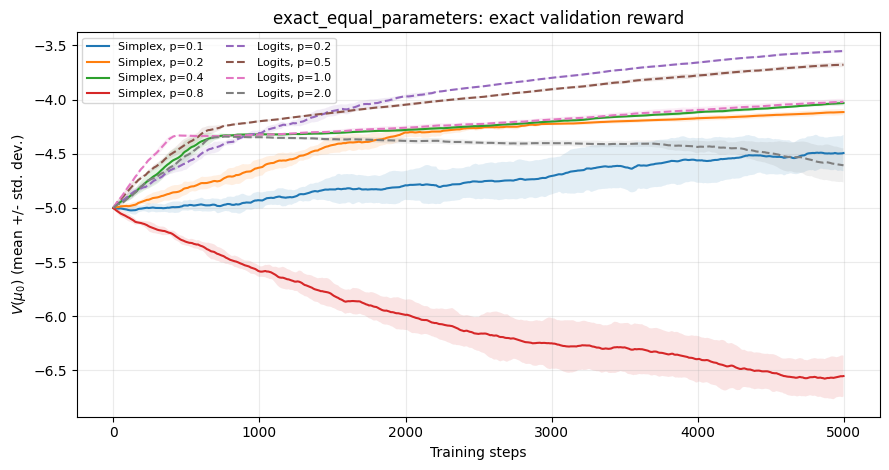

value_mean  value_std  policy_error_st_0_mean  \
algorithm parameter                                                  
Logits    0.2         -3.551736   0.011303                0.050215   
          0.5         -3.678491   0.021481                0.105645   
          1.0         -4.020666   0.028004                0.251125   
          2.0         -4.606739   0.157306                0.414278   
Simplex   0.1         -4.493338   0.167115                0.281512   
          0.2         -4.115420   0.028823                0.240019   
          0.4         -4.032314   0.022551                0.247901   
          0.8         -6.552810   0.187936                0.181315   

                     policy_error_st_0_std  policy_error_st_1_mean  \
algorithm parameter                                                  
Logits    0.2                     0.001917                0.031540   
          0.5                     0.006041                0.036177   
          1.0                     0.008452                0.047995   
          2.0                     0.016007                0.049110   
Simplex   0.1                     0.012618                0.204061   
          0.2                     0.011944                0.127156   
          0.4                     0.009854                0.058335   
          0.8                     0.012351                0.335544   

                     policy_error_st_1_std  policy_error_mean_mean  \
algorithm parameter                                                  
Logits    0.2                     0.003040                0.040877   
          0.5                     0.004306                0.070911   
          1.0                     0.006202                0.149560   
          2.0                     0.010668                0.231694   
Simplex   0.1                     0.015356                0.242787   
          0.2                     0.006104                0.183588   
          0.4                     0.003099                0.153118   
          0.8                     0.013926                0.258430   

                     policy_error_mean_std  flow_error_mean  flow_error_std  \
algorithm parameter                                                           
Logits    0.2                     0.002371         0.009684        0.000586   
          0.5                     0.004839         0.015833        0.001089   
          1.0                     0.006742         0.032322        0.001423   
          2.0                     0.008309         0.060501        0.007614   
Simplex   0.1                     0.012331         0.057274        0.008421   
          0.2                     0.008242         0.037976        0.001436   
          0.4                     0.005154         0.033054        0.001084   
          0.8                     0.009902         0.160139        0.009292   

                     runtime_seconds_mean  episodes_completed_mean  \
algorithm parameter                                                  
Logits    0.2                   61.283144                   5000.0   
          0.5                   62.663292                   5000.0   
          1.0                   66.272214                   5000.0   
          2.0                   65.780124                   5000.0   
Simplex   0.1                   32.613035                   5000.0   
          0.2                   33.689408                   5000.0   
          0.4                   34.263118                   5000.0   
          0.8                   36.526651                   5000.0   

                     best_validation_value_mean  main_trajectories_mean  \
algorithm parameter                                                       
Logits    0.2                         -3.551327                   200.0   
          0.5                         -3.678042                   200.0   
          1.0                         -4.020366                   200.0   
          2.0                         -4.337085    

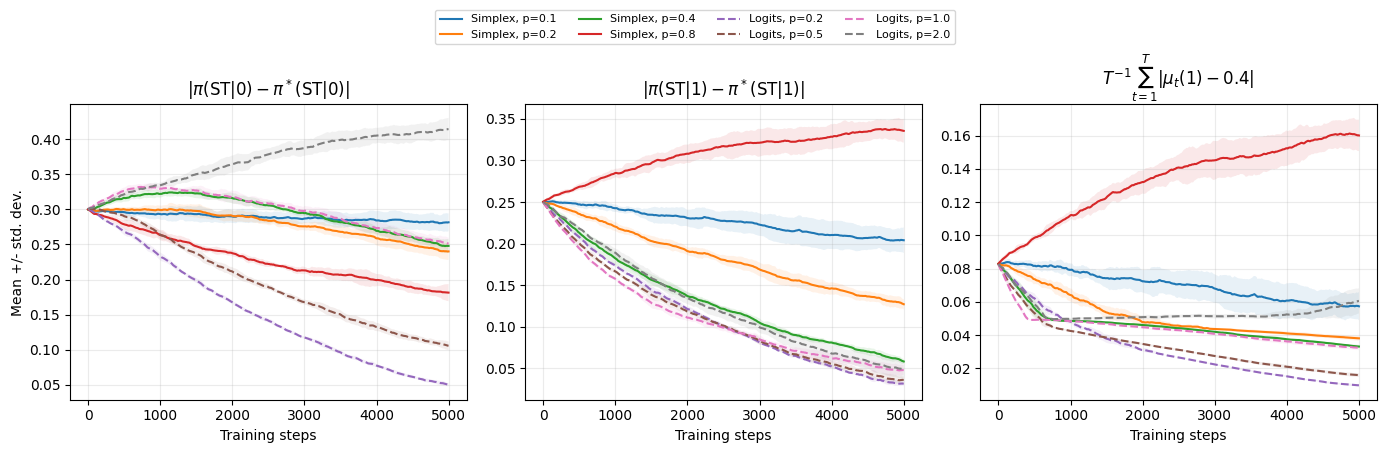

In [6]:
show_twostate_results(exact_equal_parameters, twostate_calibration)

## Exact Flow: Equal Simulator Budget

Logits uses `(B,n)=(200,10)`. Simplex uses `(B,n)=(2800,400)`, giving both methods `6400` simulated transitions per policy update for `T=2` when exact population recursion is used for the unperturbed flow.

In [7]:
exact_equal_budget = run_twostate_scenario(
    "exact_equal_budget",
    config,
    simplex_lambdas,
    logit_epsilons,
    equal_simulator_budgets,
    twostate_run_plans,
    flow_mode="exact",
    flow_particles=0,
    train_horizon=train_horizon,
    validation_horizon=validation_horizon,
    early_stopping_patience=early_stopping_patience,
    max_runtime_seconds=max_runtime_seconds,
)

,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,2800,400,2,exact,0,6400,1.0
Logits,200,10,2,exact,0,6400,1.0


exact_equal_budget Simplex p=0.1 run=0: 100%|██████████| 5000/5000 [00:43<00:00, 115.93it/s, grad=0.938, value=-3.528] 


exact_equal_budget Simplex p=0.1 run=0 value=-3.52793 cost/update=6400 runtime=43.1s


exact_equal_budget Simplex p=0.1 run=1: 100%|██████████| 5000/5000 [00:47<00:00, 104.52it/s, grad=0.0565, value=-3.525]


exact_equal_budget Simplex p=0.1 run=1 value=-3.52515 cost/update=6400 runtime=47.8s


...

exact_equal_budget Logits p=2.0 run=2 value=-4.44776 cost/update=6400 runtime=1m 27s


exact_equal_budget Logits p=2.0 run=3: 100%|██████████| 5000/5000 [01:33<00:00, 53.41it/s, grad=0.486, value=-4.525] 


exact_equal_budget Logits p=2.0 run=3 value=-4.52469 cost/update=6400 runtime=1m 33s


exact_equal_budget Logits p=2.0 run=4: 100%|██████████| 5000/5000 [01:25<00:00, 58.65it/s, grad=0.369, value=-4.53]   

exact_equal_budget Logits p=2.0 run=4 value=-4.53035 cost/update=6400 runtime=1m 25s
exact_equal_budget Logits p=2.0 completed in 6m 54s


In [8]:
exact_equal_budget_gradient_study = run_twostate_diagnostics(
    exact_equal_budget,
    config,
    simplex_lambdas,
    logit_epsilons,
    twostate_run_plans,
    repetitions=diagnostic_repetitions,
)
display(exact_equal_budget_gradient_study.round(6))

,label,algorithm,flow_mode,flow_particles,parameter,repetitions,B,n_aux_or_inner,oracle_grad_norm,mean_grad_norm,bias_norm,covariance_trace,mse,cosine_to_oracle,simulator_transitions_per_estimate,simulator_transitions
0,initial,Simplex,exact,0,0.1,64,2800,400,3.337381,2.513714,0.827021,16.776877,17.198703,0.999670,6400,409600
1,initial,Simplex,exact,0,0.2,64,2800,400,3.337381,2.273885,1.064216,0.695161,1.816854,0.999899,6400,409600
2,initial,Simplex,exact,0,0.4,64,2800,400,3.337381,1.157718,2.180885,0.068585,4.823772,0.999310,6400,409600
3,initial,Simplex,exact,0,0.8,64,2800,400,3.337381,0.017950,3.355331,0.002573,11.260779,-0.999992,6400,409600
4,initial,Logits,exact,0,0.2,64,200,10,3.337381,2.182739,1.158768,0.486974,1.822109,0.999345,6400,409600
5,initial,Logits,exact,0,0.5,64,200,10,3.337381,1.117767,2.221939,0.261454,5.194381,0.998616,6400,409600
6,initial,Logits,exact,0,1.0,64,200,10,3.337381,0.640898,2.698323,0.196128,7.474011,0.997680,6400,409600
7,initial,Logits,exact,0,2.0,64,200,10,3.337381,0.176784,3.161243,0.203189,10.193474,0.996536,6400,409600
8,simplex_final_lambda_0.4,Simplex,exact,0,0.1,64,2800,400,1.931999,1.349257,0.586468,4.515429,4.788820,0.999164,6400,409600
9,simplex_final_lambda_0.4,Simplex,exact,0,0.2,64,2800,400,1.931999,0.392435,1.545717,0.055222,2.443601,0.987481,6400,409600


exact_equal_budget


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,2800,400,2,exact,0,6400,1.0
Logits,200,10,2,exact,0,6400,1.0


,algorithm,parameter,tv_mean,tv_median,tv_std,tv_p10,tv_p90
0,Simplex,0.1,0.0257,0.0227,0.0180,0.0043,0.0518
1,Simplex,0.2,0.0513,0.0454,0.0359,0.0085,0.1035
2,Simplex,0.4,0.1027,0.0908,0.0718,0.0171,0.2070
3,Simplex,0.8,0.2054,0.1816,0.1436,0.0342,0.4141
4,Logits,0.2,0.0438,0.0351,0.0357,0.0061,0.0935
5,Logits,0.5,0.1061,0.0855,0.0854,0.0152,0.2253
6,Logits,1.0,0.1923,0.1580,0.1474,0.0302,0.4062
7,Logits,2.0,0.2985,0.2587,0.2049,0.0594,0.6048


radius  value_mean  value_std
algorithm parameter                                 
Logits    0.2        0.043767   -3.551736   0.011303
          0.5        0.106082   -3.678491   0.021481
          1.0        0.192312   -4.020666   0.028004
          2.0        0.298535   -4.606737   0.157305
Simplex   0.1        0.025669   -3.526670   0.010030
          0.2        0.051339   -3.728586   0.011444
          0.4        0.102677   -4.236571   0.015394
          0.8        0.205355   -6.429643   0.048616

value_mean_interp
algorithm matched_tv_radius                   
Logits    0.043767                   -3.551736
          0.070698                   -3.606516
          0.097630                   -3.661297
          0.124561                   -3.751816
          0.151492                   -3.858685
          0.178423                   -3.965553
          0.205355                   -4.092626
Simplex   0.043767                   -3.669026
          0.070698                   -3.920145
          0.097630                   -4.186624
          0.124561                   -4.703978
          0.151492                   -5.279200
          0.178423                   -5.854421
          0.205355                   -6.429643

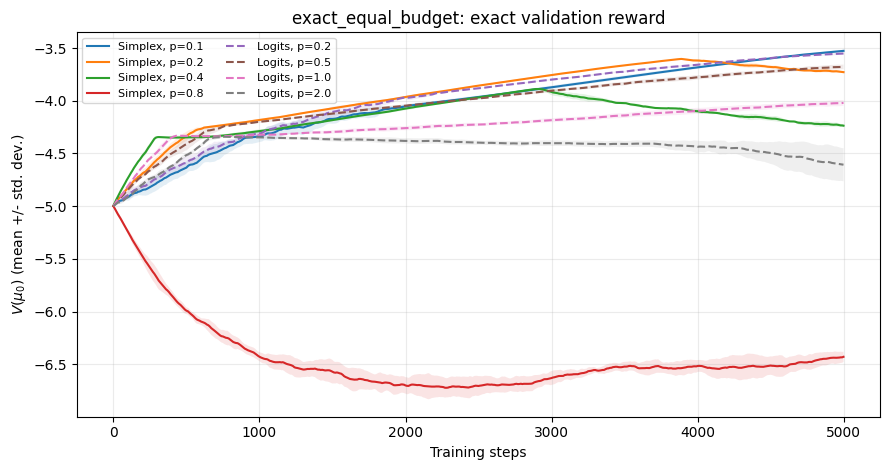

value_mean  value_std  policy_error_st_0_mean  \
algorithm parameter                                                  
Logits    0.2         -3.551736   0.011303                0.050215   
          0.5         -3.678491   0.021481                0.105645   
          1.0         -4.020666   0.028004                0.251125   
          2.0         -4.606737   0.157305                0.414278   
Simplex   0.1         -3.526670   0.010030                0.058223   
          0.2         -3.728586   0.011444                0.064463   
          0.4         -4.236571   0.015394                0.131035   
          0.8         -6.429643   0.048616                0.068131   

                     policy_error_st_0_std  policy_error_st_1_mean  \
algorithm parameter                                                  
Logits    0.2                     0.001917                0.031540   
          0.5                     0.006041                0.036177   
          1.0                     0.008452                0.047995   
          2.0                     0.016007                0.049110   
Simplex   0.1                     0.002699                0.015695   
          0.2                     0.002111                0.010385   
          0.4                     0.003706                0.033141   
          0.8                     0.004975                0.297421   

                     policy_error_st_1_std  policy_error_mean_mean  \
algorithm parameter                                                  
Logits    0.2                     0.003040                0.040877   
          0.5                     0.004306                0.070911   
          1.0                     0.006202                0.149560   
          2.0                     0.010668                0.231694   
Simplex   0.1                     0.002084                0.036959   
          0.2                     0.001000                0.037424   
          0.4                     0.002291                0.082088   
          0.8                     0.004528                0.182776   

                     policy_error_mean_std  flow_error_mean  flow_error_std  \
algorithm parameter                                                           
Logits    0.2                     0.002371         0.009684        0.000586   
          0.5                     0.004839         0.015833        0.001089   
          1.0                     0.006742         0.032322        0.001423   
          2.0                     0.008309         0.060501        0.007614   
Simplex   0.1                     0.002119         0.008245        0.000510   
          0.2                     0.001046         0.018034        0.000559   
          0.4                     0.001282         0.042783        0.000749   
          0.8                     0.004357         0.154102        0.002404   

                     runtime_seconds_mean  episodes_completed_mean  \
algorithm parameter                                                  
Logits    0.2                   82.260866                   5000.0   
          0.5                   65.823086                   5000.0   
          1.0                   67.553118                   5000.0   
          2.0                   82.821248                   5000.0   
Simplex   0.1                   43.383128                   5000.0   
          0.2                   42.143643                   5000.0   
          0.4                   38.589613                   5000.0   
          0.8                   44.959917                   5000.0   

                     best_validation_value_mean  main_trajectories_mean  \
algorithm parameter                                                       
Logits    0.2                         -3.551327                   200.0   
          0.5                         -3.678042                   200.0   
          1.0                         -4.020366                   200.0   
          2.0                         -4.337085    

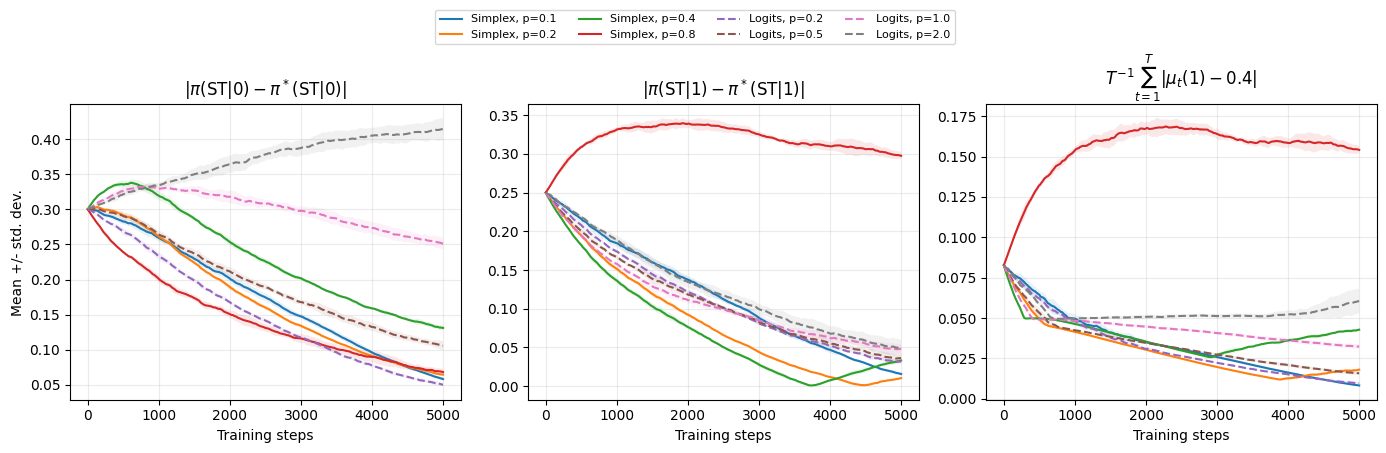

In [9]:
show_twostate_results(exact_equal_budget, twostate_calibration)

## Particle Flow: Equal Simulator Budget

Both methods condition on a one-per-update particle approximation of the unperturbed population flow. The same `flow_particles` value is used for simplex and logits, then supplied to the corresponding estimator. With `flow_particles=200`, both methods have `6400 + 200*T = 6800` simulated transitions per policy update for `T=2`.

In [10]:
particle_equal_budget = run_twostate_scenario(
    "particle_equal_budget",
    config,
    simplex_lambdas,
    logit_epsilons,
    equal_simulator_budgets,
    twostate_run_plans,
    flow_mode="particle",
    flow_particles=particle_flow_particles,
    train_horizon=train_horizon,
    validation_horizon=validation_horizon,
    early_stopping_patience=early_stopping_patience,
    max_runtime_seconds=max_runtime_seconds,
)

,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,2800,400,2,particle,200,6800,1.0
Logits,200,10,2,particle,200,6800,1.0


particle_equal_budget Simplex p=0.1 run=0: 100%|██████████| 5000/5000 [00:40<00:00, 123.66it/s, grad=0.688, value=-3.821] 


particle_equal_budget Simplex p=0.1 run=0 value=-3.82107 cost/update=6800 runtime=40.4s


particle_equal_budget Simplex p=0.1 run=1: 100%|██████████| 5000/5000 [00:42<00:00, 116.34it/s, grad=2.02, value=-3.79]   


particle_equal_budget Simplex p=0.1 run=1 value=-3.7899 cost/update=6800 runtime=43.0s


...

particle_equal_budget Logits p=2.0 run=2 value=-4.42343 cost/update=6800 runtime=1m 50s


particle_equal_budget Logits p=2.0 run=3: 100%|██████████| 5000/5000 [01:54<00:00, 43.81it/s, grad=0.733, value=-4.641] 


particle_equal_budget Logits p=2.0 run=3 value=-4.64105 cost/update=6800 runtime=1m 54s


particle_equal_budget Logits p=2.0 run=4: 100%|██████████| 5000/5000 [01:49<00:00, 45.78it/s, grad=0.357, value=-4.458] 


particle_equal_budget Logits p=2.0 run=4 value=-4.45845 cost/update=6800 runtime=1m 49s
particle_equal_budget Logits p=2.0 completed in 9m 13s


In [11]:
particle_equal_budget_gradient_study = run_twostate_diagnostics(
    particle_equal_budget,
    config,
    simplex_lambdas,
    logit_epsilons,
    twostate_run_plans,
    repetitions=diagnostic_repetitions,
)
display(particle_equal_budget_gradient_study.round(6))

,label,algorithm,flow_mode,flow_particles,parameter,repetitions,B,n_aux_or_inner,oracle_grad_norm,mean_grad_norm,bias_norm,covariance_trace,mse,cosine_to_oracle,simulator_transitions_per_estimate,simulator_transitions
0,initial,Simplex,particle,200,0.1,64,2800,400,3.337381,2.194788,1.142618,7.957255,9.138500,0.999996,6800,435200
1,initial,Simplex,particle,200,0.2,64,2800,400,3.337381,1.948319,1.392637,0.909475,2.834702,0.999235,6800,435200
2,initial,Simplex,particle,200,0.4,64,2800,400,3.337381,1.178900,2.159225,0.151223,4.811114,0.999591,6800,435200
3,initial,Simplex,particle,200,0.8,64,2800,400,3.337381,0.026157,3.363537,0.002591,11.315929,-0.999959,6800,435200
4,initial,Logits,particle,200,0.2,64,200,10,3.337381,1.952423,1.388056,1.284914,3.191538,0.999341,6800,435200
5,initial,Logits,particle,200,0.5,64,200,10,3.337381,1.198648,2.143474,0.408690,4.996784,0.997462,6800,435200
6,initial,Logits,particle,200,1.0,64,200,10,3.337381,0.591863,2.746001,0.262680,7.799097,0.999328,6800,435200
7,initial,Logits,particle,200,2.0,64,200,10,3.337381,0.264323,3.075140,0.189085,9.642615,0.992745,6800,435200
8,simplex_final_lambda_0.4,Simplex,particle,200,0.1,64,2800,400,2.092572,1.305976,0.787013,7.922956,8.418550,0.999880,6800,435200
9,simplex_final_lambda_0.4,Simplex,particle,200,0.2,64,2800,400,2.092572,0.151057,2.059419,0.417208,4.651897,0.253824,6800,435200


particle_equal_budget


,B,n,horizon,flow_mode,flow_particles,simulator_transitions_per_update,ratio_vs_simplex
algorithm,,,,,,,
Simplex,2800,400,2,particle,200,6800,1.0
Logits,200,10,2,particle,200,6800,1.0


,algorithm,parameter,tv_mean,tv_median,tv_std,tv_p10,tv_p90
0,Simplex,0.1,0.0257,0.0227,0.0180,0.0043,0.0518
1,Simplex,0.2,0.0513,0.0454,0.0359,0.0085,0.1035
2,Simplex,0.4,0.1027,0.0908,0.0718,0.0171,0.2070
3,Simplex,0.8,0.2054,0.1816,0.1436,0.0342,0.4141
4,Logits,0.2,0.0438,0.0351,0.0357,0.0061,0.0935
5,Logits,0.5,0.1061,0.0855,0.0854,0.0152,0.2253
6,Logits,1.0,0.1923,0.1580,0.1474,0.0302,0.4062
7,Logits,2.0,0.2985,0.2587,0.2049,0.0594,0.6048


radius  value_mean  value_std
algorithm parameter                                 
Logits    0.2        0.043767   -3.666271   0.009503
          0.5        0.106082   -3.746303   0.008717
          1.0        0.192312   -4.039494   0.023834
          2.0        0.298535   -4.517114   0.094299
Simplex   0.1        0.025669   -3.807494   0.011982
          0.2        0.051339   -3.637903   0.006104
          0.4        0.102677   -4.146851   0.046680
          0.8        0.205355   -6.434077   0.052183

value_mean_interp
algorithm matched_tv_radius                   
Logits    0.043767                   -3.666271
          0.070698                   -3.700859
          0.097630                   -3.735447
          0.124561                   -3.809132
          0.151492                   -3.900701
          0.178423                   -3.992270
          0.205355                   -4.098138
Simplex   0.043767                   -3.687927
          0.070698                   -3.829825
          0.097630                   -4.096809
          0.124561                   -4.634324
          0.151492                   -5.234242
          0.178423                   -5.834159
          0.205355                   -6.434077

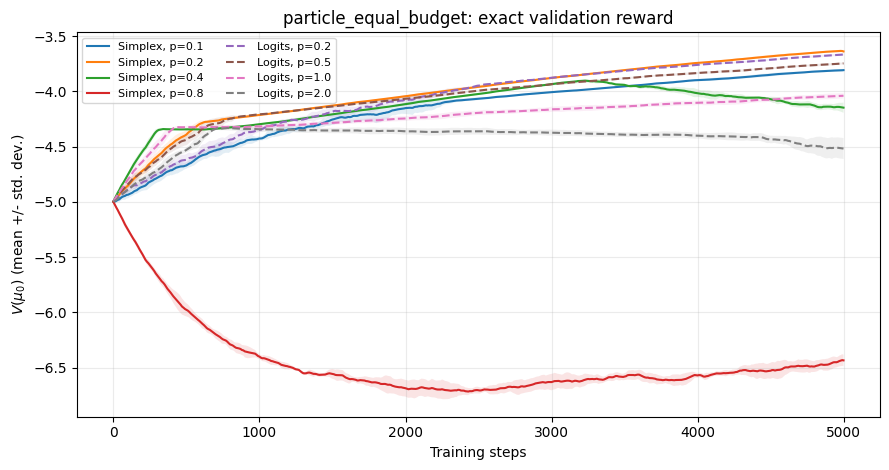

value_mean  value_std  policy_error_st_0_mean  \
algorithm parameter                                                  
Logits    0.2         -3.666271   0.009503                0.078344   
          0.5         -3.746303   0.008717                0.120500   
          1.0         -4.039494   0.023834                0.253221   
          2.0         -4.517114   0.094299                0.411144   
Simplex   0.1         -3.807494   0.011982                0.129002   
          0.2         -3.637903   0.006104                0.102971   
          0.4         -4.146851   0.046680                0.151518   
          0.8         -6.434077   0.052183                0.068765   

                     policy_error_st_0_std  policy_error_st_1_mean  \
algorithm parameter                                                  
Logits    0.2                     0.004084                0.055148   
          0.5                     0.003499                0.052260   
          1.0                     0.007419                0.055824   
          2.0                     0.011200                0.055707   
Simplex   0.1                     0.000760                0.073436   
          0.2                     0.001296                0.019713   
          0.4                     0.001581                0.015241   
          0.8                     0.003459                0.297933   

                     policy_error_st_1_std  policy_error_mean_mean  \
algorithm parameter                                                  
Logits    0.2                     0.001980                0.066746   
          0.5                     0.002555                0.086380   
          1.0                     0.007716                0.154522   
          2.0                     0.008382                0.233425   
Simplex   0.1                     0.006236                0.101219   
          0.2                     0.004683                0.061342   
          0.4                     0.004048                0.083379   
          0.8                     0.003726                0.183349   

                     policy_error_mean_std  flow_error_mean  flow_error_std  \
algorithm parameter                                                           
Logits    0.2                     0.002295         0.015514        0.000471   
          0.5                     0.002060         0.019319        0.000439   
          1.0                     0.005939         0.033350        0.001233   
          2.0                     0.007913         0.056158        0.004574   
Simplex   0.1                     0.003047         0.022541        0.000655   
          0.2                     0.002027         0.013644        0.000335   
          0.4                     0.002723         0.038408        0.002273   
          0.8                     0.002234         0.154321        0.002582   

                     runtime_seconds_mean  episodes_completed_mean  \
algorithm parameter                                                  
Logits    0.2                   72.058282                   5000.0   
          0.5                   75.724329                   5000.0   
          1.0                  120.550871                   5000.0   
          2.0                  110.645109                   5000.0   
Simplex   0.1                   41.810025                   5000.0   
          0.2                   47.172978                   5000.0   
          0.4                   48.625523                   5000.0   
          0.8                   47.084447                   5000.0   

                     best_validation_value_mean  main_trajectories_mean  \
algorithm parameter                                                       
Logits    0.2                         -3.666041                   200.0   
          0.5                         -3.746303                   200.0   
          1.0                         -4.039061                   200.0   
          2.0                         -4.326986    

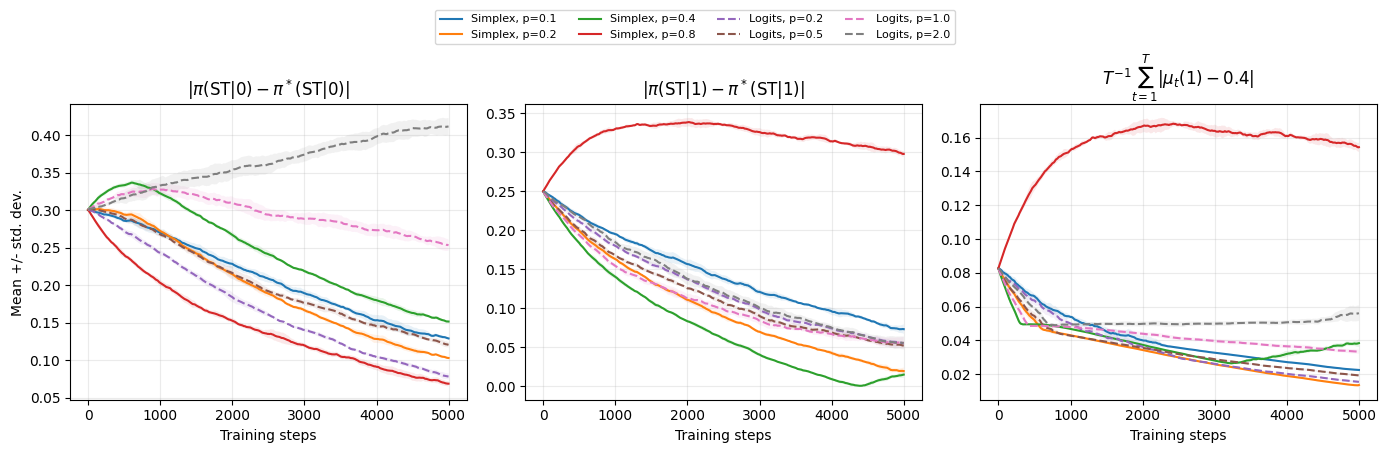

In [12]:
show_twostate_results(particle_equal_budget, twostate_calibration)

## Cross-Protocol Summary

Compare terminal metrics across exact-flow and particle-flow settings.

In [13]:
scenario_tables = []
for scenario in [exact_equal_parameters, exact_equal_budget, particle_equal_budget]:
    table = summarize_metric_rows(
        scenario["results"],
        ["value", "policy_error_st_0", "policy_error_st_1", "policy_error_mean", "flow_error"],
    ).reset_index()
    table.insert(0, "scenario", scenario["name"])
    table.insert(1, "flow_mode", scenario["flow_mode"])
    table.insert(2, "flow_particles", scenario["flow_particles"])
    scenario_tables.append(table)

cross_protocol_summary = pd.concat(scenario_tables, ignore_index=True)
display(cross_protocol_summary.round(6))

,scenario,flow_mode,flow_particles,algorithm,parameter,value_mean,value_std,policy_error_st_0_mean,policy_error_st_0_std,policy_error_st_1_mean,...,policy_error_mean_std,flow_error_mean,flow_error_std,runtime_seconds_mean,episodes_completed_mean,best_validation_value_mean,main_trajectories_mean,auxiliary_trajectories_mean,simulator_transitions_per_update_mean,total_simulator_transitions_mean
0,exact_equal_parameters,exact,0,Logits,0.2,-3.551736,0.011303,0.050215,0.001917,0.031540,...,0.002371,0.009684,0.000586,61.283144,5000.0,-3.551327,200.0,10.0,6400.0,32000000.0
1,exact_equal_parameters,exact,0,Logits,0.5,-3.678491,0.021481,0.105645,0.006041,0.036177,...,0.004839,0.015833,0.001089,62.663292,5000.0,-3.678042,200.0,10.0,6400.0,32000000.0
2,exact_equal_parameters,exact,0,Logits,1.0,-4.020666,0.028004,0.251125,0.008452,0.047995,...,0.006742,0.032322,0.001423,66.272214,5000.0,-4.020366,200.0,10.0,6400.0,32000000.0
3,exact_equal_parameters,exact,0,Logits,2.0,-4.606739,0.157306,0.414278,0.016007,0.049110,...,0.008309,0.060501,0.007614,65.780124,5000.0,-4.337085,200.0,10.0,6400.0,32000000.0
4,exact_equal_parameters,exact,0,Simplex,0.1,-4.493338,0.167115,0.281512,0.012618,0.204061,...,0.012331,0.057274,0.008421,32.613035,5000.0,-4.469531,200.0,10.0,420.0,2100000.0
5,exact_equal_parameters,exact,0,Simplex,0.2,-4.115420,0.028823,0.240019,0.011944,0.127156,...,0.008242,0.037976,0.001436,33.689408,5000.0,-4.114994,200.0,10.0,420.0,2100000.0
6,exact_equal_parameters,exact,0,Simplex,0.4,-4.032314,0.022551,0.247901,0.009854,0.058335,...,0.005154,0.033054,0.001084,34.263118,5000.0,-4.032217,200.0,10.0,420.0,2100000.0
7,exact_equal_parameters,exact,0,Simplex,0.8,-6.552810,0.187936,0.181315,0.012351,0.335544,...,0.009902,0.160139,0.009292,36.526651,5000.0,-5.001572,200.0,10.0,420.0,2100000.0
8,exact_equal_budget,exact,0,Logits,0.2,-3.551736,0.011303,0.050215,0.001917,0.031540,...,0.002371,0.009684,0.000586,82.260866,5000.0,-3.551327,200.0,10.0,6400.0,32000000.0
9,exact_equal_budget,exact,0,Logits,0.5,-3.678491,0.021481,0.105645,0.006041,0.036177,...,0.004839,0.015833,0.001089,65.823086,5000.0,-3.678042,200.0,10.0,6400.0,32000000.0
